In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df['who'].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [5]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [6]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
df.shape

(891, 15)

In [9]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
df = df.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], axis=1)

In [11]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,True
887,1,1,female,19.0,0,0,30.0000,S,True
888,0,3,female,NaN,1,2,23.4500,S,False
889,1,1,male,26.0,0,0,30.0000,C,True


In [12]:
df['age'] = df['age'].fillna(df['age'].mean())

In [13]:
df = df.dropna(subset='embarked')

In [14]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [15]:
df['alone'] = df['alone'].astype(int)

In [16]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.000000,1,0,7.2500,S,0
1,1,1,female,38.000000,1,0,71.2833,C,0
2,1,3,female,26.000000,0,0,7.9250,S,1
3,1,1,female,35.000000,1,0,53.1000,S,0
4,0,3,male,35.000000,0,0,8.0500,S,1
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,1
887,1,1,female,19.000000,0,0,30.0000,S,1
888,0,3,female,29.699118,1,2,23.4500,S,0
889,1,1,male,26.000000,0,0,30.0000,C,1


In [17]:
X = df.drop('survived', axis=1)

In [18]:
y = df['survived']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
ohe = OneHotEncoder(sparse_output=False, drop='first')

In [21]:
X_train

,pclass,sex,age,sibsp,parch,fare,embarked,alone
708,1,female,22.000000,0,0,151.5500,S,1
240,3,female,29.699118,1,0,14.4542,C,0
382,3,male,32.000000,0,0,7.9250,S,1
792,3,female,29.699118,8,2,69.5500,S,0
683,3,male,14.000000,5,2,46.9000,S,0
...,...,...,...,...,...,...,...,...
107,3,male,29.699118,0,0,7.7750,S,1
271,3,male,25.000000,0,0,0.0000,S,1
862,1,female,48.000000,0,0,25.9292,S,1
436,3,female,21.000000,2,2,34.3750,S,0


In [22]:
ohe.fit(X_train[['sex', 'embarked']])

OneHotEncoder(drop='first', sparse_output=False)

In [23]:
X_train[ohe.get_feature_names_out()] = ohe.transform(X_train[['sex', 'embarked']])

In [24]:
X_train

,pclass,sex,age,sibsp,parch,fare,embarked,alone,sex_male,embarked_Q,embarked_S
708,1,female,22.000000,0,0,151.5500,S,1,0.0,0.0,1.0
240,3,female,29.699118,1,0,14.4542,C,0,0.0,0.0,0.0
382,3,male,32.000000,0,0,7.9250,S,1,1.0,0.0,1.0
792,3,female,29.699118,8,2,69.5500,S,0,0.0,0.0,1.0
683,3,male,14.000000,5,2,46.9000,S,0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
107,3,male,29.699118,0,0,7.7750,S,1,1.0,0.0,1.0
271,3,male,25.000000,0,0,0.0000,S,1,1.0,0.0,1.0
862,1,female,48.000000,0,0,25.9292,S,1,0.0,0.0,1.0
436,3,female,21.000000,2,2,34.3750,S,0,0.0,0.0,1.0


In [25]:
X_train = X_train.drop(columns=['sex', 'embarked'])

In [26]:
X_train

,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
708,1,22.000000,0,0,151.5500,1,0.0,0.0,1.0
240,3,29.699118,1,0,14.4542,0,0.0,0.0,0.0
382,3,32.000000,0,0,7.9250,1,1.0,0.0,1.0
792,3,29.699118,8,2,69.5500,0,0.0,0.0,1.0
683,3,14.000000,5,2,46.9000,0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
107,3,29.699118,0,0,7.7750,1,1.0,0.0,1.0
271,3,25.000000,0,0,0.0000,1,1.0,0.0,1.0
862,1,48.000000,0,0,25.9292,1,0.0,0.0,1.0
436,3,21.000000,2,2,34.3750,0,0.0,0.0,1.0


In [27]:
X_test[ohe.get_feature_names_out()] = ohe.transform(X_test[['sex', 'embarked']])

In [28]:
X_test

,pclass,sex,age,sibsp,parch,fare,embarked,alone,sex_male,embarked_Q,embarked_S
281,3,male,28.0,0,0,7.8542,S,1,1.0,0.0,1.0
435,1,female,14.0,1,2,120.0000,S,0,0.0,0.0,1.0
39,3,female,14.0,1,0,11.2417,C,0,0.0,0.0,0.0
418,2,male,30.0,0,0,13.0000,S,1,1.0,0.0,1.0
585,1,female,18.0,0,2,79.6500,S,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
433,3,male,17.0,0,0,7.1250,S,1,1.0,0.0,1.0
807,3,female,18.0,0,0,7.7750,S,1,0.0,0.0,1.0
25,3,female,38.0,1,5,31.3875,S,0,0.0,0.0,1.0
85,3,female,33.0,3,0,15.8500,S,0,0.0,0.0,1.0


In [29]:
X_test = X_test.drop(columns=['sex', 'embarked'])

In [30]:
model = LogisticRegression()

In [31]:
model.fit(X_train, y_train)

LogisticRegression()

In [32]:
y_pred = model.predict(X_test)

In [33]:
y_pred

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [34]:
model.classes_

array([0, 1])

In [35]:
y_proba = model.predict_proba(X_test)

In [36]:
y_proba

array([[0.90439855, 0.09560145],
       [0.04696242, 0.95303758],
       [0.18788034, 0.81211966],
       [0.76791862, 0.23208138],
       [0.03274779, 0.96725221],
       [0.90049608, 0.09950392],
       [0.72549113, 0.27450887],
       [0.87345918, 0.12654082],
       [0.07835402, 0.92164598],
       [0.05023439, 0.94976561],
       [0.63605734, 0.36394266],
       [0.3427075 , 0.6572925 ],
       [0.96378516, 0.03621484],
       [0.83769172, 0.16230828],
       [0.90812   , 0.09188   ],
       [0.90351105, 0.09648895],
       [0.59440096, 0.40559904],
       [0.87626708, 0.12373292],
       [0.71741164, 0.28258836],
       [0.91079834, 0.08920166],
       [0.85030221, 0.14969779],
       [0.04474922, 0.95525078],
       [0.9141906 , 0.0858094 ],
       [0.41816303, 0.58183697],
       [0.91078961, 0.08921039],
       [0.53311779, 0.46688221],
       [0.75026357, 0.24973643],
       [0.11857937, 0.88142063],
       [0.50644807, 0.49355193],
       [0.7346907 , 0.2653093 ],
       [0.

In [37]:
y_proba[:, 0]

array([0.90439855, 0.04696242, 0.18788034, 0.76791862, 0.03274779,
       0.90049608, 0.72549113, 0.87345918, 0.07835402, 0.05023439,
       0.63605734, 0.3427075 , 0.96378516, 0.83769172, 0.90812   ,
       0.90351105, 0.59440096, 0.87626708, 0.71741164, 0.91079834,
       0.85030221, 0.04474922, 0.9141906 , 0.41816303, 0.91078961,
       0.53311779, 0.75026357, 0.11857937, 0.50644807, 0.7346907 ,
       0.4885602 , 0.29609687, 0.91078961, 0.48606313, 0.97070181,
       0.55017713, 0.25493833, 0.39419093, 0.87615498, 0.91078961,
       0.87064513, 0.3541644 , 0.70723093, 0.89633606, 0.55728374,
       0.53254903, 0.18438083, 0.88773969, 0.79840898, 0.06605439,
       0.06261849, 0.20637314, 0.87840868, 0.84180033, 0.06599327,
       0.13299308, 0.392292  , 0.93942808, 0.84641815, 0.76822892,
       0.77309309, 0.43728794, 0.15257984, 0.84639249, 0.181773  ,
       0.65864072, 0.96215802, 0.90142772, 0.07976049, 0.03979812,
       0.74302625, 0.02734109, 0.28747617, 0.90039067, 0.47178

In [38]:
y_proba[:, 1]

array([0.09560145, 0.95303758, 0.81211966, 0.23208138, 0.96725221,
       0.09950392, 0.27450887, 0.12654082, 0.92164598, 0.94976561,
       0.36394266, 0.6572925 , 0.03621484, 0.16230828, 0.09188   ,
       0.09648895, 0.40559904, 0.12373292, 0.28258836, 0.08920166,
       0.14969779, 0.95525078, 0.0858094 , 0.58183697, 0.08921039,
       0.46688221, 0.24973643, 0.88142063, 0.49355193, 0.2653093 ,
       0.5114398 , 0.70390313, 0.08921039, 0.51393687, 0.02929819,
       0.44982287, 0.74506167, 0.60580907, 0.12384502, 0.08921039,
       0.12935487, 0.6458356 , 0.29276907, 0.10366394, 0.44271626,
       0.46745097, 0.81561917, 0.11226031, 0.20159102, 0.93394561,
       0.93738151, 0.79362686, 0.12159132, 0.15819967, 0.93400673,
       0.86700692, 0.607708  , 0.06057192, 0.15358185, 0.23177108,
       0.22690691, 0.56271206, 0.84742016, 0.15360751, 0.818227  ,
       0.34135928, 0.03784198, 0.09857228, 0.92023951, 0.96020188,
       0.25697375, 0.97265891, 0.71252383, 0.09960933, 0.52821

In [39]:
cm = confusion_matrix(y_test, y_pred)

In [40]:
cm

array([[88, 21],
       [15, 54]])

In [41]:
pd.DataFrame(cm, columns=model.classes_, index=model.classes_)

,0,1
0,88,21
1,15,54


In [42]:
acc = accuracy_score(y_test, y_pred)

In [43]:
acc

0.797752808988764

In [44]:
ps = precision_score(y_test, y_pred)

In [45]:
ps

0.72

In [46]:
rs = recall_score(y_test, y_pred)

In [47]:
rs

0.782608695652174

In [48]:
f1 = f1_score(y_test, y_pred)

In [49]:
f1

0.75

In [50]:
print(classification_report(y_test,  y_pred))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       109
           1       0.72      0.78      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



AUC: 0.8531445286531048


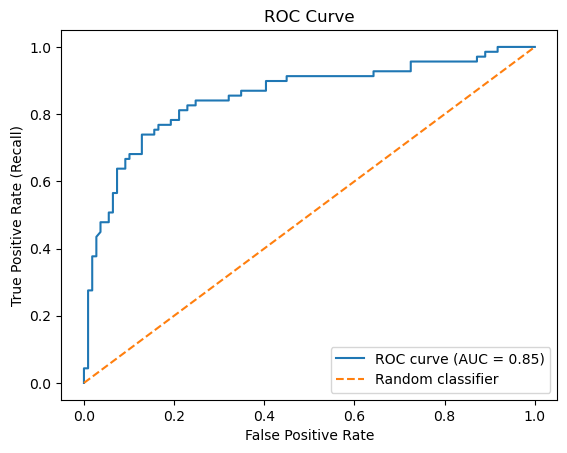

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])

# AUC
auc = roc_auc_score(y_test, y_proba[:, 1])

print("AUC:", auc)

# Plot ROC curve
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [52]:
from sklearn.tree import DecisionTreeClassifier

In [53]:
model = DecisionTreeClassifier()

In [54]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [55]:
y_pred = model.predict(X_test)

In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.74      0.79       109
           1       0.65      0.77      0.71        69

    accuracy                           0.75       178
   macro avg       0.74      0.76      0.75       178
weighted avg       0.76      0.75      0.76       178



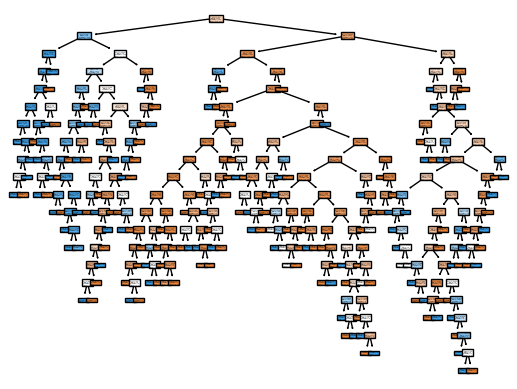

In [59]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plot_tree(model, filled=True)
plt.show()

In [61]:
model.predict_proba(X_test[0:10])

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.]])

In [62]:
model.tree_

In [63]:
model.feature_importances_

array([0.09407319, 0.25123413, 0.04006997, 0.05531335, 0.2193669 ,
       0.00974428, 0.29437788, 0.01360552, 0.0222148 ])

In [64]:
model.feature_names_in_

array(['pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'sex_male',
       'embarked_Q', 'embarked_S'], dtype=object)